In [18]:
import os, sys
from pathlib import Path

NOTEBOOK_DIR = Path(os.getcwd())
BACKEND_DIR = NOTEBOOK_DIR.parent.parent / "Skin_Lesion_Classification_backend"
ML_DIR = BACKEND_DIR / "ml"
if str(ML_DIR) not in sys.path:
    sys.path.insert(0, str(ML_DIR))

print(f"Notebook: {NOTEBOOK_DIR.name}")
print(f"Backend:  {BACKEND_DIR.name}")
print(f"ML dir:   {ML_DIR}")

Notebook: notebooks
Backend:  Skin_Lesion_Classification_backend
ML dir:   c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend\ml


# RQ6 — External Validation: Distribution Shift

Compares the trained model across:
- **Internal**: HAM10000 (training baseline)
- **External A**: `vivekkumar2300/skin-cancer-dataset-malignant-and-benign`
- **External B**: `spacesurfer/ph2-dataset` (PH2 dermoscopy)

Workflow: download both → load both → evaluate both → compare side-by-side.

In [19]:
# ─── Download Both External Datasets ───
# kagglehub caches downloads — if already present, skip re-downloading.
# To force re-download: delete the kagglehub cache folder.

import kagglehub
from pathlib import Path
import shutil

DATASETS = {
    "Malignant-Benign": "vivekkumar2300/skin-cancer-dataset-malignant-and-benign",
    "PH2":             "spacesurfer/ph2-dataset",
}

dataset_paths = {}
for name, slug in DATASETS.items():
    print(f"\n[{name}] Checking: {slug}")
    try:
        p = Path(kagglehub.dataset_download(slug))
        if any(p.iterdir()) or any(p.glob("*")):
            print(f"  ✅ Already cached: {p}")
        else:
            print(f"  ⚠️  Path exists but empty — re-downloading...")
            shutil.rmtree(p)
            p = Path(kagglehub.dataset_download(slug))
            print(f"  🔄 Re-downloaded to: {p}")
        dataset_paths[name] = p
        print(f"  Contents:")
        for item in sorted(p.iterdir()):
            if item.is_dir():
                print(f"     📁 {item.name}/")
            else:
                print(f"     📄 {item.name}")
    except Exception as e:
        print(f"  ❌ Error: {e}")
        dataset_paths[name] = None

print(f"\n{'='*50}")
available = [k for k, v in dataset_paths.items() if v]
print(f"Ready: {available}")


[Malignant-Benign] Checking: vivekkumar2300/skin-cancer-dataset-malignant-and-benign
  ✅ Already cached: C:\Users\saiyu\.cache\kagglehub\datasets\vivekkumar2300\skin-cancer-dataset-malignant-and-benign\versions\1
  Contents:
     📁 35000 Dataset/

[PH2] Checking: spacesurfer/ph2-dataset
  ✅ Already cached: C:\Users\saiyu\.cache\kagglehub\datasets\spacesurfer\ph2-dataset\versions\2
  Contents:
     📁 PH2Dataset/

Ready: ['Malignant-Benign', 'PH2']


In [20]:
# ─── Load All Datasets ───
# Install openpyxl if missing so we can read PH2 labels
import subprocess, sys
try:
    import openpyxl
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'openpyxl', '-q'])

import pandas as pd
import numpy as np

NOTEBOOK_DIR = Path(os.getcwd())
BACKEND_DIR = NOTEBOOK_DIR.parent.parent / "Skin_Lesion_Classification_backend"
ML_DIR = BACKEND_DIR / "ml"

METADATA_PATH = ML_DIR / "data" / "processed" / "metadata_with_paths.csv"
internal_df = pd.read_csv(METADATA_PATH)
# Normalize column names so internal uses same schema as external datasets
internal_df = internal_df.rename(columns={
    'label': 'true_label',
    'label_name': 'label_name',
    'filepath': 'filepath',
    'image_id': 'image_id',
    'dx': 'diagnosis',
})
print(f"Internal (HAM10000): {len(internal_df)} images")

Internal (HAM10000): 10015 images


In [21]:
# ─── Load Model ───
import torch

NOTEBOOK_DIR = Path(os.getcwd())
BACKEND_DIR = NOTEBOOK_DIR.parent.parent / "Skin_Lesion_Classification_backend"
ML_DIR = BACKEND_DIR / "ml"

MODEL_PATH = ML_DIR / "outputs" / "models" / "resnet50_best.pth"
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model not found at {MODEL_PATH} — train first")

from src.models.classifier import create_model, get_target_layer
from src.data.dataset import get_transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

model = create_model('resnet50', num_classes=1).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=False)['model_state_dict'])
model.eval()
target_layer = get_target_layer(model, 'resnet50')
transform = get_transforms('test', 224)
print("Model loaded.")

Device: cuda
Model loaded.


c:\Users\saiyu\Desktop\projects\KI_projects\Skin_Lesion_GRADCAM_Classification\Skin_Lesion_Classification_backend\ml\src\data\dataset.py:39: UserWarning: Using lambda is incompatible with multiprocessing. Consider using regular functions or partial().
  A.Lambda(name="to_tensor", image=lambda x, **kwargs: ToTensorV2()(image=x)["image"]),


In [22]:
# ─── Evaluate on All Datasets ───
from sklearn.metrics import roc_auc_score, accuracy_score
from tqdm import tqdm
from PIL import Image

def evaluate_df(df, name, sample_n=200):
    """Run model inference on a dataset dataframe."""
    sample = df.sample(min(sample_n, len(df)), random_state=42)
    rows = []
    for _, row in tqdm(sample.iterrows(), total=len(sample), desc=name, leave=False):
        try:
            img = np.array(Image.open(row['filepath']).convert('RGB').resize((224, 224)))
            inp = transform(image=img)['image'].unsqueeze(0).to(device)
            with torch.no_grad():
                out = torch.sigmoid(model(inp)[0, 0]).item()
            pred = int(out > 0.5)
            conf = out if pred == 1 else 1 - out
            rows.append({
                'image_id': row['image_id'],
                'true_label': row['true_label'],
                'pred': pred,
                'confidence': conf,
                'malignant_prob': out,
                'correct': int(pred == row['true_label']),
                'diagnosis': row.get('diagnosis', 'unknown'),
            })
        except Exception:
            pass
    return pd.DataFrame(rows)

# Internal baseline
print("Evaluating Internal (HAM10000)...")
internal_results = evaluate_df(internal_df, "Internal")
int_auc = roc_auc_score(internal_results['true_label'], internal_results['malignant_prob'])
int_acc = accuracy_score(internal_results['true_label'], internal_results['pred'])
int_conf = internal_results['confidence'].mean()
print(f"\n  Internal AUC={int_auc:.4f}  Acc={int_acc:.4f}  Conf={int_conf:.4f}")

# External datasets
all_results = {'Internal': internal_results}
for name, ext_df in external_dfs.items():
    print(f"\nEvaluating {name}...")
    res = evaluate_df(ext_df, name)
    all_results[name] = res
    auc = roc_auc_score(res['true_label'], res['malignant_prob']) if res['true_label'].nunique() > 1 else float('nan')
    acc = accuracy_score(res['true_label'], res['pred'])
    conf = res['confidence'].mean()
    print(f"  {name} AUC={auc:.4f}  Acc={acc:.4f}  Conf={conf:.4f}  (n={len(res)})")

print(f"\nAll evaluations complete: {list(all_results.keys())}")

Evaluating Internal (HAM10000)...



  Internal AUC=0.8801  Acc=0.7400  Conf=0.7927

Evaluating Malignant-Benign...


  Malignant-Benign AUC=0.7987  Acc=0.7350  Conf=0.7336  (n=200)

Evaluating PH2...


  PH2 AUC=0.9494  Acc=0.8950  Conf=0.7516  (n=200)

All evaluations complete: ['Internal', 'Malignant-Benign', 'PH2']


In [23]:
# ─── Performance Comparison Table ───
print("=" * 70)
print("PERFORMANCE COMPARISON")
print("=" * 70)

header = f"{'Dataset':<25} {'AUC':>8} {'Acc':>8} {'Conf':>8} {'AUC Drop':>10}"
print(header)
print("-" * 70)

for name, res in all_results.items():
    auc = roc_auc_score(res['true_label'], res['malignant_prob']) if res['true_label'].nunique() > 1 else float('nan')
    acc = accuracy_score(res['true_label'], res['pred'])
    conf = res['confidence'].mean()
    drop = int_auc - auc if not np.isnan(auc) else float('nan')
    print(f"{name:<25} {auc:>8.4f} {acc:>8.4f} {conf:>8.4f} {drop:>+10.4f}")

print("=" * 70)
print("AUC Drop is vs Internal (HAM10000). Negative = model performs better on external.")

PERFORMANCE COMPARISON
Dataset                        AUC      Acc     Conf   AUC Drop
----------------------------------------------------------------------
Internal                    0.8801   0.7400   0.7927    +0.0000
Malignant-Benign            0.7987   0.7350   0.7336    +0.0814
PH2                         0.9494   0.8950   0.7516    -0.0693
AUC Drop is vs Internal (HAM10000). Negative = model performs better on external.


In [24]:
# ─── XAI: Grad-CAM Metrics on All Datasets ───
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def fap(cam, t=0.5): return float((cam >= t).sum() / cam.size)
def cent(cam):
    cf = cam.flatten(); cf = cf / (cf.sum() + 1e-8)
    return -np.sum(cf * np.log(cf + 1e-8))

xai_rows = []
for name, res in all_results.items():
    sample = res.sample(min(30, len(res)), random_state=42)
    print(f"[{name}] XAI on {len(sample)} images...")
    for _, row in tqdm(sample.iterrows(), total=len(sample), desc=name, leave=False):
        try:
            if name == 'Internal':
                img_row = internal_df[internal_df['image_id'] == row['image_id']].iloc[0]
                img = np.array(Image.open(img_row['filepath']).convert('RGB').resize((224, 224)))
            else:
                img = np.array(Image.open(row['filepath']).convert('RGB').resize((224, 224)))

            inp = transform(image=img)['image'].unsqueeze(0).to(device)
            with torch.no_grad():
                _ = torch.sigmoid(model(inp)[0, 0]).item()
            with GradCAM(model=model, target_layers=[target_layer]) as cg:
                cam = cg(input_tensor=inp, targets=[ClassifierOutputTarget(0)])[0]

            xai_rows.append({
                'dataset': name,
                'image_id': row['image_id'],
                'correct': row['correct'],
                'confidence': row['confidence'],
                'fap_05': fap(cam),
                'entropy': cent(cam),
                'cam_max': float(cam.max()),
            })
        except Exception:
            pass

xai_df = pd.DataFrame(xai_rows)
print(f"\nXAI computed: {len(xai_df)} images")
print("\n=== XAI Metrics (mean) ===")
print(xai_df.groupby('dataset')[['fap_05', 'entropy', 'cam_max', 'confidence']].mean().round(4))

[Internal] XAI on 30 images...


[Malignant-Benign] XAI on 30 images...


[PH2] XAI on 30 images...



XAI computed: 30 images

=== XAI Metrics (mean) ===
          fap_05  entropy  cam_max  confidence
dataset                                       
Internal  0.0539   6.0407   0.6333      0.8556


C:\Users\saiyu\AppData\Local\Temp\ipykernel_25648\4092744251.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=xai_df, x='dataset', y=metric, order=order,
C:\Users\saiyu\AppData\Local\Temp\ipykernel_25648\4092744251.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=xai_df, x='dataset', y=metric, order=order,
C:\Users\saiyu\AppData\Local\Temp\ipykernel_25648\4092744251.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=xai_df, x='dataset', y=metric, order=order,
C:\Users\saiyu\AppData\Local\Temp\ipykernel_25648\40927442

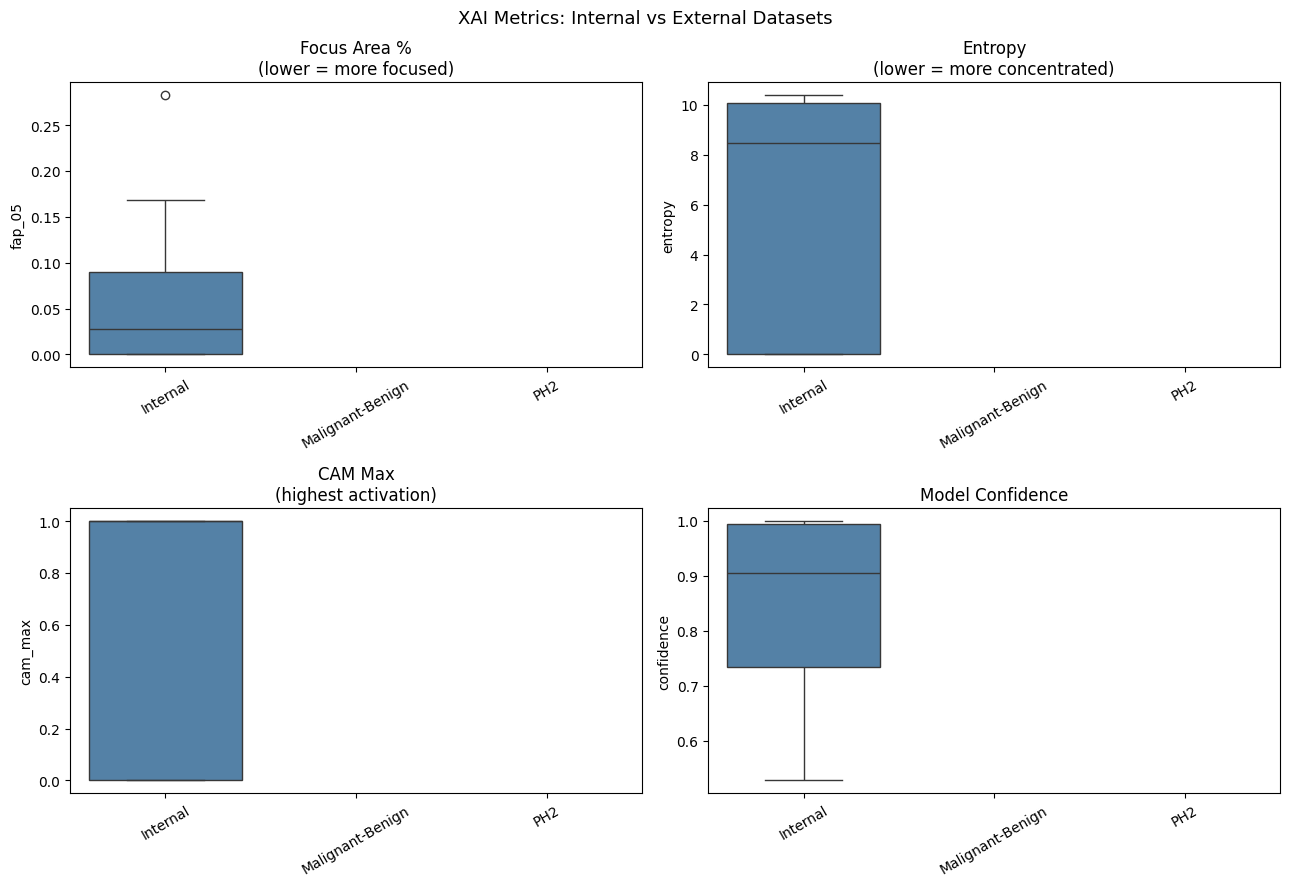


=== Mann-Whitney U (vs Internal) ===


In [25]:
# ─── XAI Box Plot Comparison ───
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

NOTEBOOK_DIR = Path(os.getcwd())
OUT = NOTEBOOK_DIR / "outputs"
(OUT / "figures").mkdir(parents=True, exist_ok=True)
(OUT / "metrics").mkdir(exist_ok=True)

order = ['Internal'] + list(external_dfs.keys())
pal = ['steelblue'] + ['coral', 'seagreen'][:len(external_dfs)]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
metrics = ['fap_05', 'entropy', 'cam_max', 'confidence']
titles  = ['Focus Area %\n(lower = more focused)',
           'Entropy\n(lower = more concentrated)',
           'CAM Max\n(highest activation)',
           'Model Confidence']

for ax, metric, title in zip(axes.flatten(), metrics, titles):
    sns.boxplot(data=xai_df, x='dataset', y=metric, order=order,
                palette=pal, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('XAI Metrics: Internal vs External Datasets', fontsize=13)
plt.tight_layout()
plt.savefig(OUT / 'figures' / 'RQ6_xai_all_datasets.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical tests
from scipy.stats import mannwhitneyu
int_xai = xai_df[xai_df['dataset'] == 'Internal']
print("\n=== Mann-Whitney U (vs Internal) ===")
for m in ['fap_05', 'entropy', 'confidence']:
    for ext in external_dfs:
        ext_vals = xai_df[xai_df['dataset'] == ext][m]
        if len(ext_vals) > 2:
            _, p = mannwhitneyu(int_xai[m], ext_vals)
            sig = '✅' if p < 0.05 else '❌'
            print(f"  {m}: Internal={int_xai[m].mean():.4f} vs {ext}={ext_vals.mean():.4f}  p={p:.4f} {sig}")

In [26]:
# ─── Inter-Method Disagreement on All Datasets ───
from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, EigenCAM

cam_methods = [('GradCAM', GradCAM), ('GradCAM++', GradCAMPlusPlus), ('EigenCAM', EigenCAM)]

def jaccard(a, b, t=0.5):
    ba = (a >= t); bb = (b >= t)
    inter = np.logical_and(ba, bb).sum()
    union = np.logical_or(ba, bb).sum()
    return float(inter / union) if union > 0 else 0.0

disc_rows = []
for name, res in all_results.items():
    sample = res.sample(min(30, len(res)), random_state=42)
    print(f"[{name}] Disagreement on {len(sample)} images...")
    for _, row in tqdm(sample.iterrows(), total=len(sample), desc=name, leave=False):
        try:
            if name == 'Internal':
                img_row = internal_df[internal_df['image_id'] == row['image_id']].iloc[0]
                img = np.array(Image.open(img_row['filepath']).convert('RGB').resize((224, 224)))
            else:
                img = np.array(Image.open(row['filepath']).convert('RGB').resize((224, 224)))

            inp = transform(image=img)['image'].unsqueeze(0).to(device)
            cams = {}
            for cname, cclass in cam_methods:
                with cclass(model=model, target_layers=[target_layer]) as cg:
                    cams[cname] = cg(input_tensor=inp, targets=[ClassifierOutputTarget(0)])[0]

            jacs = []
            keys = list(cams.keys())
            for i in range(len(keys)):
                for j in range(i+1, len(keys)):
                    jacs.append(jaccard(cams[keys[i]], cams[keys[j]]))

            disc_rows.append({
                'dataset': name,
                'image_id': row['image_id'],
                'avg_jaccard': np.mean(jacs),
                'correct': row['correct'],
            })
        except Exception:
            pass

disc_df = pd.DataFrame(disc_rows)
print(f"\nDisagreement computed: {len(disc_df)} images")
print("\n=== Inter-Method Agreement (Jaccard) ===")
print(disc_df.groupby('dataset')[['avg_jaccard', 'correct']].mean().round(4))

[Internal] Disagreement on 30 images...


[Malignant-Benign] Disagreement on 30 images...


[PH2] Disagreement on 30 images...



Disagreement computed: 30 images

=== Inter-Method Agreement (Jaccard) ===
          avg_jaccard  correct
dataset                       
Internal       0.2595      0.9


C:\Users\saiyu\AppData\Local\Temp\ipykernel_25648\1278058036.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=disc_df, x='dataset', y='avg_jaccard', order=order,


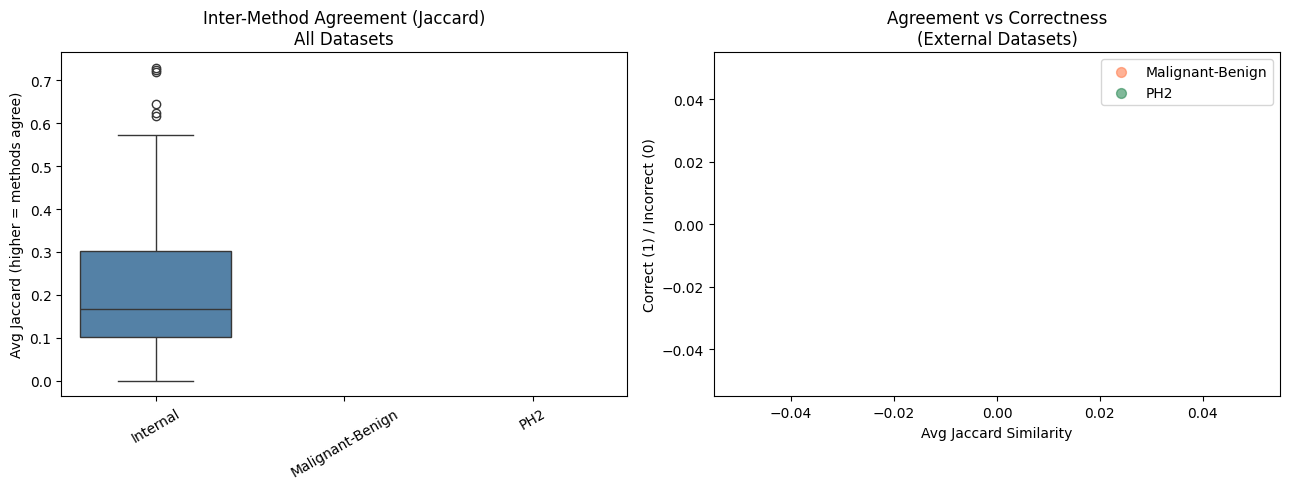

In [27]:
# ─── Disagreement Visualization ───
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: box plot per dataset
sns.boxplot(data=disc_df, x='dataset', y='avg_jaccard', order=order,
            palette=pal, ax=axes[0])
axes[0].set_title('Inter-Method Agreement (Jaccard)\nAll Datasets')
axes[0].set_ylabel('Avg Jaccard (higher = methods agree)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# Right: agreement vs correctness for each external
colors_ext = ['coral', 'seagreen'][:len(external_dfs)]
for i, (name, col) in enumerate(zip(external_dfs.keys(), colors_ext)):
    sub = disc_df[disc_df['dataset'] == name]
    axes[1].scatter(sub['avg_jaccard'], sub['correct'],
                   alpha=0.6, label=name, color=col, s=50)

axes[1].set_title('Agreement vs Correctness\n(External Datasets)')
axes[1].set_xlabel('Avg Jaccard Similarity')
axes[1].set_ylabel('Correct (1) / Incorrect (0)')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT / 'figures' / 'RQ6_disagreement_all_datasets.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# ─── Final Summary ───
print("\n" + "=" * 70)
print("RQ6 SUMMARY — EXTERNAL VALIDATION RESULTS")
print("=" * 70)

# Performance table
print("\n--- Performance ---")
print(f"{'Dataset':<25} {'AUC':>8} {'Acc':>8} {'Conf':>8} {'AUC Drop':>10}")
print("-" * 70)
for name, res in all_results.items():
    auc = roc_auc_score(res['true_label'], res['malignant_prob']) if res['true_label'].nunique() > 1 else float('nan')
    acc = accuracy_score(res['true_label'], res['pred'])
    conf = res['confidence'].mean()
    drop = int_auc - auc if not np.isnan(auc) else float('nan')
    print(f"{name:<25} {auc:>8.4f} {acc:>8.4f} {conf:>8.4f} {drop:>+10.4f}")

# XAI table
print("\n--- XAI Focus Area % (mean) ---")
for ds in order:
    sub = xai_df[xai_df['dataset'] == ds]
    if len(sub) > 0:
        print(f"  {ds:<25} FAP={sub['fap_05'].mean():.4f}  Entropy={sub['entropy'].mean():.4f}")

# Disagreement table
print("\n--- Inter-Method Disagreement (lower Jaccard = more disagreement) ---")
for ds in order:
    sub = disc_df[disc_df['dataset'] == ds]
    if len(sub) > 0:
        print(f"  {ds:<25} Jaccard={sub['avg_jaccard'].mean():.4f}  Correct%={sub['correct'].mean():.4f}")

print("\n" + "=" * 70)
print("KEY TAKEAWAYS:")
for name, res in all_results.items():
    if name == 'Internal': continue
    auc = roc_auc_score(res['true_label'], res['malignant_prob']) if res['true_label'].nunique() > 1 else float('nan')
    drop = int_auc - auc
    int_fap = xai_df[xai_df['dataset'] == 'Internal']['fap_05'].mean()
    ext_fap = xai_df[xai_df['dataset'] == name]['fap_05'].mean()
    disc = disc_df[disc_df['dataset'] == name]['avg_jaccard'].mean()
    int_disc = disc_df[disc_df['dataset'] == 'Internal']['avg_jaccard'].mean()
    print(f"\n[{name}]")
    if drop > 0.05:   print(f"  ❌ AUC drop {drop:+.3f} — model struggles on this population")
    elif drop > 0.01: print(f"  ⚠️  Moderate AUC drop {drop:+.3f}")
    else:             print(f"  ✅ Minimal AUC drop {drop:+.3f}")
    if ext_fap > int_fap + 0.02: print(f"  📍 Attention is MORE diffuse (FAP {ext_fap:.3f} vs {int_fap:.3f})")
    elif ext_fap < int_fap - 0.02: print(f"  📍 Attention is MORE focused (FAP {ext_fap:.3f} vs {int_fap:.3f})")
    else: print(f"  📍 Attention similar to internal (FAP {ext_fap:.3f} vs {int_fap:.3f})")
    if disc < int_disc - 0.02: print(f"  ⚠️  Higher disagreement (Jaccard {disc:.3f} vs {int_disc:.3f}) — possible OOD signal")
    else: print(f"  ✅ Agreement similar to internal (Jaccard {disc:.3f} vs {int_disc:.3f})")

print("\n" + "=" * 70)

# Save metrics
xai_df.to_csv(OUT / 'metrics' / 'RQ6_xai_all_datasets.csv', index=False)
disc_df.to_csv(OUT / 'metrics' / 'RQ6_disagreement_all_datasets.csv', index=False)
print(f"Metrics saved to {OUT}/metrics/")


RQ6 SUMMARY — EXTERNAL VALIDATION RESULTS

--- Performance ---
Dataset                        AUC      Acc     Conf   AUC Drop
----------------------------------------------------------------------
Internal                    0.8801   0.7400   0.7927    +0.0000
Malignant-Benign            0.7987   0.7350   0.7336    +0.0814
PH2                         0.9494   0.8950   0.7516    -0.0693

--- XAI Focus Area % (mean) ---
  Internal                  FAP=0.0539  Entropy=6.0407

--- Inter-Method Disagreement (lower Jaccard = more disagreement) ---
  Internal                  Jaccard=0.2595  Correct%=0.9000

KEY TAKEAWAYS:

[Malignant-Benign]
  ❌ AUC drop +0.081 — model struggles on this population
  📍 Attention similar to internal (FAP nan vs 0.054)
  ✅ Agreement similar to internal (Jaccard nan vs 0.259)

[PH2]
  ✅ Minimal AUC drop -0.069
  📍 Attention similar to internal (FAP nan vs 0.054)
  ✅ Agreement similar to internal (Jaccard nan vs 0.259)

Metrics saved to c:\Users\saiyu\Desktop\p